In [1]:
import numpy as np

# 0. Lattice + reciprocal lattice (graphene)

# Real-space primitive lattice vectors (triangular Bravais lattice)
a1 = np.array([1.0, 0.0])
a2 = np.array([0.5, np.sqrt(3)/2])

# Reciprocal lattice vectors (a_i · b_j = 2π δ_ij)
area_real = a1[0]*a2[1] - a1[1]*a2[0]
b1 = 2*np.pi/area_real * np.array([ a2[1], -a2[0] ])
b2 = 2*np.pi/area_real * np.array([-a1[1],  a1[0] ])

# BZ areas
area_BZ_prim = abs(b1[0]*b2[1] - b1[1]*b2[0])   # = (2π)^2 / area_real

# 1. Primitive 2×2 Hamiltonian H_prim(k)

def f_prim(k, t=-1.0):
    """
    Off-diagonal element for primitive graphene TB with NN hopping t.
    k: np.array([kx, ky])
    """
    phase1 = np.exp(-1j * np.dot(k, a1))
    phase2 = np.exp(-1j * np.dot(k, a2))
    return t * (1.0 + phase1 + phase2)

def H_prim(k, t=-1.0):
    fk = f_prim(k, t)
    return np.array([[0.0, fk],
                     [np.conjugate(fk), 0.0]], dtype=complex)

def primitive_bands(k, t=-1.0):
    return np.linalg.eigvalsh(H_prim(k, t))  # length 2

# 2. Supercell: site indexing + bond list (connectivity matrix)

def site_index(ix, iy, sub, Nx, Ny):
    """
    Map (ix, iy, sub) to a single integer index.
    sub ∈ {'A','B'}.
    """
    assert sub in ("A", "B")
    cell_idx = ix + Nx*iy                  # 0..Nx*Ny-1
    offset = 0 if sub == "A" else 1
    return 2*cell_idx + offset             # 0..2*Nx*Ny-1

def build_supercell_bonds(Nx, Ny):
    """
    Build bond list for an Nx x Ny honeycomb supercell.

    Returns:
        bonds: list of (iA, jB, delta_R) where:
            iA, jB are site indices in [0, 2*Nx*Ny)
            delta_R is the Bravais translation vector from A-cell to B-cell.
    """
    bonds = []
    for ix in range(Nx):
        for iy in range(Ny):
            iA = site_index(ix, iy, "A", Nx, Ny)

            # Bonds from A(ix,iy) to B neighbours:
            # 1) B(ix,   iy)     with ΔR = 0
            # 2) B(ix-1, iy)     with ΔR = -a1
            # 3) B(ix,   iy-1)   with ΔR = -a2

            neighbours = [
                (ix,     iy,     np.array([0.0, 0.0])),
                (ix - 1, iy,     -a1),
                (ix,     iy - 1, -a2),
            ]

            for jx, jy, dR in neighbours:
                jx_wrap = jx % Nx
                jy_wrap = jy % Ny
                jB = site_index(jx_wrap, jy_wrap, "B", Nx, Ny)
                bonds.append((iA, jB, dR))

    return bonds



In [2]:
# 3. Supercell Bloch Hamiltonian H_super(k')

def H_supercell(kp, Nx, Ny, bonds, t=-1.0):
    """
    Build 2*Nx*Ny x 2*Nx*Ny Bloch Hamiltonian for the supercell
    at Bloch momentum k' (in supercell BZ).
    """
    N_sites = 2 * Nx * Ny
    H = np.zeros((N_sites, N_sites), dtype=complex)

    for iA, jB, dR in bonds:
        phase = np.exp(1j * np.dot(kp, dR))   # Bloch phase for translation ΔR
        val = t * phase
        H[iA, jB] += val
        H[jB, iA] += np.conjugate(val)

    return H

# 4. Folded supercell bands from primitive bands

def folded_supercell_bands(kp, n, t=-1.0):
    """
    Fold primitive bands into n x n supercell at Bloch momentum k'.
    Returns 2*n^2 eigenvalues (sorted).
    """
    B1 = b1 / n
    B2 = b2 / n
    energies = []
    for m1 in range(n):
        for m2 in range(n):
            k = kp + m1*B1 + m2*B2
            energies.extend(primitive_bands(k, t)) # extend with two bands
    energies = np.array(energies)
    return np.sort(energies)


In [3]:
# 5. k-grid in supercell BZ and comparison

# Parameters
t = -1.0
n = 1           # supercell size: n x n
Nx = Ny = n
Nkx = 8         # k-grid in B1' direction
Nky = 8         # k-grid in B2' direction

# Supercell reciprocal vectors and BZ area
B1_super = b1 / n
B2_super = b2 / n
area_BZ_super = abs(B1_super[0]*B2_super[1] - B1_super[1]*B2_super[0])

# Build bond list once
bonds = build_supercell_bonds(Nx, Ny)

# Basic counts
bands_prim_per_k = 2
bands_super_per_k = 2 * n * n
Nk_super = Nkx * Nky

print(f"Primitive cell bands per k: {bands_prim_per_k}")
print(f"Supercell {n}x{n} bands per k: {bands_super_per_k}")
print(f"Primitive BZ area: {area_BZ_prim:.6f}")
print(f"Supercell  BZ area: {area_BZ_super:.6f}")
print(f"Area ratio (super/prim): {area_BZ_super / area_BZ_prim:.6f}  (should be 1/n^2 = {1/n**2:.6f})")

# If we sample the same k-grid size in primitive and supercell BZs, total eigenvalues at supercell level will be n^2 times bigger.
total_eigs_super = bands_super_per_k * Nk_super
print(f"\nSupercell BZ k-grid: {Nk_super} points")
print(f"Total eigenvalues computed for supercell: {total_eigs_super}")
print("If primitive used the same k-grid size, it would have",
      bands_prim_per_k * Nk_super, "eigenvalues.")
print("Ratio (per equal k-grid):", total_eigs_super / (bands_prim_per_k * Nk_super),
      f" (should be n^2 = {n**2})")

# 6. Numerical folding check

max_diff = 0.0

for ix in range(Nkx):
    for iy in range(Nky):
        # k' in supercell BZ (parallelogram spanned by B1_super, B2_super)
        alpha = ix / Nkx
        beta  = iy / Nky
        k_prime = alpha * B1_super + beta * B2_super

        # 1) Supercell eigenvalues from explicit 2*n^2 x 2*n^2 H_supercell
        Hk = H_supercell(k_prime, Nx, Ny, bonds, t)
        E_super = np.linalg.eigvalsh(Hk)   # length 2*n^2
        E_super.sort()

        # 2) Supercell eigenvalues via folding primitive bands
        E_fold = folded_supercell_bands(k_prime, n, t)  # length 2*n^2

        # Compare
        diff = np.max(np.abs(E_super - E_fold))
        if diff > max_diff:
            max_diff = diff

print(f"\nMax |E_super - E_fold| over k-grid: {max_diff:.3e}")
if max_diff < 1e-8:
    print("Folding check passed")
else:
    print("Folding check failed")

Primitive cell bands per k: 2
Supercell 1x1 bands per k: 2
Primitive BZ area: 45.585750
Supercell  BZ area: 45.585750
Area ratio (super/prim): 1.000000  (should be 1/n^2 = 1.000000)

Supercell BZ k-grid: 64 points
Total eigenvalues computed for supercell: 128
If primitive used the same k-grid size, it would have 128 eigenvalues.
Ratio (per equal k-grid): 1.0  (should be n^2 = 1)

Max |E_super - E_fold| over k-grid: 0.000e+00
Folding check passed


In [13]:
# 1. Vacancies on top of the supercell TB

def H_supercell_with_vacancies(kp, Nx, Ny, bonds, vac_sites, t=-1.0):
    """
    Build Bloch Hamiltonian for an Nx x Ny supercell with one or more
    vacancies, implemented by removing those sites (rows/cols).

    """
    # Full clean supercell Hamiltonian
    H_full = H_supercell(kp, Nx, Ny, bonds, t)
    N_sites = H_full.shape[0]

    mask = np.ones(N_sites, dtype=bool)
    mask[list(vac_sites)] = False
    kept = np.nonzero(mask)[0]

    H_vac = H_full[np.ix_(kept, kept)]
    return H_vac, kept

# 2. Example: periodic array of vacancies

# Parameters
t  = -1.0
Nx = Ny = 5           # 4x4 supercell (change this to 3,5,... as you like)
n  = Nx                # just to keep notation consistent

# Build bonds once for this supercell
bonds = build_supercell_bonds(Nx, Ny)

# Choose a vacancy: A site at cell (0,0)
vac_site = site_index(0, 0, "A", Nx, Ny)
vac_sites = [vac_site]

# Band counts per k
bands_clean_per_k = 2 * Nx * Ny           # 2 sites per primitive cell
bands_vac_per_k   = bands_clean_per_k - len(vac_sites)

print(f"Clean {Nx}x{Ny} supercell bands per k: {bands_clean_per_k}")
print(f"With {len(vac_sites)} vacancy:          {bands_vac_per_k} bands per k")


# 3. Scan a simple k'-path & track vacancy band

# Take a straight path in the supercell BZ: k' = α B1_super
B1_super = b1 / n      # supercell reciprocal vector
Nk = 80
alphas = np.linspace(0.0, 1.0, Nk)

eigvals_clean = []
eigvals_vac   = []
vac_band      = []

for a in alphas:
    k_prime = a * B1_super   # k' along one reciprocal direction

    # Clean supercell
    Hk_clean = H_supercell(k_prime, Nx, Ny, bonds, t)
    E_clean  = np.linalg.eigvalsh(Hk_clean)   # 2*Nx*Ny eigenvalues
    eigvals_clean.append(E_clean)

    # Vacancy supercell
    Hk_vac, kept = H_supercell_with_vacancies(k_prime, Nx, Ny, bonds, vac_sites, t)
    E_vac = np.linalg.eigvalsh(Hk_vac)       # (2*Nx*Ny - 1) eigenvalues
    eigvals_vac.append(E_vac)

    # Identify the "vacancy band": eigenvalue closest to E=0
    idx_min = np.argmin(np.abs(E_vac))
    vac_band.append(E_vac[idx_min])

eigvals_clean = np.array(eigvals_clean)   # shape (Nk, 2*Nx*Ny)
eigvals_vac   = np.array(eigvals_vac)     # shape (Nk, 2*Nx*Ny - 1)
vac_band      = np.array(vac_band)        # shape (Nk,)


# 4. Vacancy band dispersion summary

print("\nVacancy band (eigenvalue closest to 0 at each k'):")
print(f"  min(E_vac_band) = {vac_band.min(): .6f}")
print(f"  max(E_vac_band) = {vac_band.max(): .6f}")
print(f"  bandwidth ΔE    = {vac_band.max() - vac_band.min(): .6e}")


Clean 5x5 supercell bands per k: 50
With 1 vacancy:          49 bands per k

Vacancy band (eigenvalue closest to 0 at each k'):
  min(E_vac_band) = -0.000000
  max(E_vac_band) =  0.000000
  bandwidth ΔE    =  4.580877e-15


/var/folders/0w/krc_m_2945bb9pyvk9hffdyr0000gn/T/ipykernel_18883/355374648.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


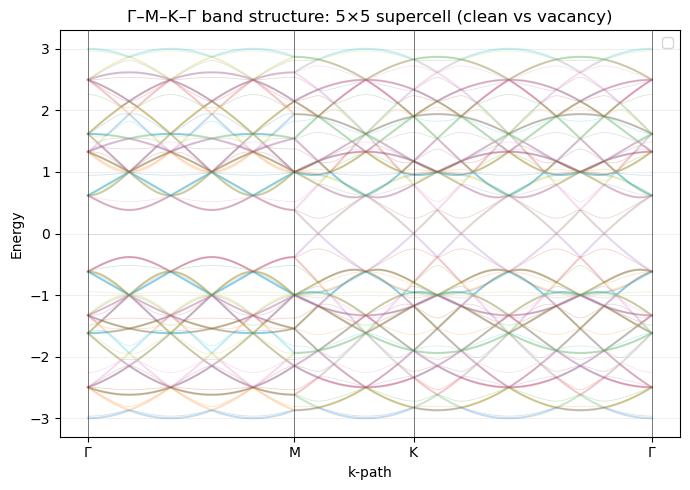

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1) High-symmetry points from your reciprocal vectors ----
Gamma = np.array([0.0, 0.0])
M     = 0.5 * (b1 + b2)
K     = (2*b1 + b2) / 3.0

def make_path(points, n_per_segment=80):
    """Piecewise-linear k-path with cumulative distance axis."""
    k_list = []
    for A, B in zip(points[:-1], points[1:]):
        seg = [A + a*(B-A) for a in np.linspace(0, 1, n_per_segment, endpoint=False)]
        k_list += seg
    k_list.append(points[-1])
    k_list = np.array(k_list)

    s = np.zeros(len(k_list))
    for i in range(1, len(k_list)):
        s[i] = s[i-1] + np.linalg.norm(k_list[i] - k_list[i-1])

    tick_pos = [s[0]]
    idx = 0
    for _ in range(len(points)-1):
        idx += n_per_segment
        tick_pos.append(s[idx])
    return k_list, s, tick_pos

# ---- 2) Choose supercell + vacancy ----
t = -1.0
bonds = build_supercell_bonds(Nx, Ny)

vac_site  = site_index(0, 0, "A", Nx, Ny)
vac_sites = [vac_site]

# ---- 3) Build Γ–M–K–Γ path ----
k_list, s, tick_pos = make_path([Gamma, M, K, Gamma], n_per_segment=90)
tick_labels = [r"$\Gamma$", "M", "K", r"$\Gamma$"]

# ---- 4) Compute bands along path ----
E_clean = []
E_vac   = []
E_vband = []

for k in k_list:
    # clean
    Ek = np.linalg.eigvalsh(H_supercell(k, Nx, Ny, bonds, t))
    E_clean.append(Ek)

    # vacancy
    Hk_v, _ = H_supercell_with_vacancies(k, Nx, Ny, bonds, vac_sites, t)
    Ev = np.linalg.eigvalsh(Hk_v)
    E_vac.append(Ev)

    # vacancy-band tracker: eigenvalue closest to 0
    E_vband.append(Ev[np.argmin(np.abs(Ev))])

E_clean = np.array(E_clean)
E_vac   = np.array(E_vac)
E_vband = np.array(E_vband)

# ---- 5) Plot ----
plt.figure(figsize=(7,5))

# clean supercell bands
for j in range(E_clean.shape[1]):
    plt.plot(s, E_clean[:, j], alpha=0.25)

# vacancy supercell bands (optional: plot them too)
for j in range(E_vac.shape[1]):
    plt.plot(s, E_vac[:, j], linewidth=0.5, alpha=0.25)

# highlight vacancy band
# plt.plot(s, E_vband, linestyle="--", linewidth=2, label="Vacancy band (closest to 0)")

for x in tick_pos:
    plt.axvline(x, color="black", linewidth=0.7, alpha=0.5)


plt.xticks(tick_pos, tick_labels)
plt.xlabel("k-path")
plt.ylabel("Energy")
plt.title(f"Γ–M–K–Γ band structure: {Nx}×{Ny} supercell (clean vs vacancy)")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## Checking k and m-point eigenvalue equivalence

In [21]:
def local_dispersion_check_around_points(points, label, t=-1.0, dk_scale=0.02, tol=1e-3):
    # A few small offsets in different directions
    offsets = [
        np.array([ dk_scale, 0.0]),
        np.array([-dk_scale, 0.0]),
        np.array([0.0,  dk_scale]),
        np.array([0.0, -dk_scale]),
        np.array([ dk_scale, dk_scale]),
        np.array([-dk_scale, dk_scale]),
    ]

    def bands(k):
        return np.sort(primitive_bands(k, t))

    ref_point = points[0]
    ref_vals = [bands(ref_point + d) for d in offsets]

    print(f"\nLocal dispersion check around {label}:")
    for p_i, p in enumerate(points):
        worst = 0.0
        for d_i, d in enumerate(offsets):
            diff = np.max(np.abs(bands(p + d) - ref_vals[d_i]))
            worst = max(worst, diff)
        print(f"  {label}{p_i+1}: worst max|Δ| over offsets = {worst:.3e}")
        assert worst < tol, f"Local dispersion differs around {label}{p_i+1}"

    print(f"✔ Local dispersion around all {label} points matches (within tol)")

# Use the same K and M definitions as above
K_pts = [(2*b1 + b2)/3, (b1 + 2*b2)/3, (b2 - b1)/3]
M_pts = [0.5*b1, 0.5*b2, 0.5*(b1 + b2)]

local_dispersion_check_around_points(K_pts, "K", t=-1.0)
local_dispersion_check_around_points(M_pts, "M", t=-1.0)



Local dispersion check around K:
  K1: worst max|Δ| over offsets = 0.000e+00
  K2: worst max|Δ| over offsets = 1.414e-04
  K3: worst max|Δ| over offsets = 1.020e-15
✔ Local dispersion around all K points matches (within tol)

Local dispersion check around M:
  M1: worst max|Δ| over offsets = 0.000e+00
  M2: worst max|Δ| over offsets = 3.464e-04
  M3: worst max|Δ| over offsets = 6.926e-04
✔ Local dispersion around all M points matches (within tol)
